# Imports

In [1]:
!pip install torchinfo

In [2]:
import torch
import torchvision
from torchvision.models import resnet18, densenet121, vgg16, mobilenet_v3_large
from torchvision.transforms import v2
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [4]:
from google.colab import drive
import os

drive.mount('/content/drive')

default_notebook_path = '/content/drive/MyDrive/Kristiania/5th_Semester/Deep_Learning/Mandatory_Assignment'
if os.path.exists(default_notebook_path):
    cifar10data = os.path.join(default_notebook_path, 'cifar10_data')
else:
    cifar10data = '/content/drive/MyDrive/Kristiania/5th_Semester/Deep_Learning/Mandatory_Assignment/cifar10_data'

os.makedirs(cifar10data, exist_ok=True)
print(f"CIFAR-10 datasets will be saved/loaded from: {cifar10data}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CIFAR-10 datasets will be saved/loaded from: /content/drive/MyDrive/Kristiania/5th_Semester/Deep_Learning/Mandatory_Assignment/cifar10_data


# Defining Three Architectures

In [5]:
# (I'll remove name later)
# Note: Baseline
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),
            nn.Conv2d(64, 140, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(140 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def get_cifar_mobilenet_v3():
    model = mobilenet_v3_large(weights=None, num_classes=10)
    # Adapt for 32x32 CIFAR-10 inputs (reduce first stride to prevent downsampling the resolution too quickly)
    model.features[0][0] = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
    return model

def get_cifar_densenet121():
    model = densenet121(weights=None, num_classes=10)
    model.features.conv0 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)   # Modify the first convolutional layer and pooling for 32x32 inputs
    model.features.pool0 = nn.Identity()
    return model

architectures = {
    "baseline_simple_cnn": SimpleCNN,
    "mobilenet_v3": get_cifar_mobilenet_v3,
    "densenet121": get_cifar_densenet121
}

In [6]:
from torchinfo import summary

# Create temporary model instances to inspect them with a batch of 64 images of size 32x32.
print("=== SimpleCNN Summary ===")
simple_cnn = SimpleCNN()
print(summary(simple_cnn, input_size=(64, 3, 32, 32)))

print("\n=== MobileNetV3 Summary ===")
mobilenet_model = get_cifar_mobilenet_v3()
print(summary(mobilenet_model, input_size=(64, 3, 32, 32)))

print("\n=== DenseNet121 Summary ===")
densenet_model = get_cifar_densenet121()
print(summary(densenet_model, input_size=(64, 3, 32, 32)))

=== SimpleCNN Summary ===
Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [64, 10]                  --
├─Sequential: 1-1                        [64, 140, 8, 8]           --
│    └─Conv2d: 2-1                       [64, 32, 32, 32]          896
│    └─LeakyReLU: 2-2                    [64, 32, 32, 32]          --
│    └─Conv2d: 2-3                       [64, 32, 32, 32]          9,248
│    └─LeakyReLU: 2-4                    [64, 32, 32, 32]          --
│    └─Conv2d: 2-5                       [64, 64, 32, 32]          18,496
│    └─ReLU: 2-6                         [64, 64, 32, 32]          --
│    └─MaxPool2d: 2-7                    [64, 64, 16, 16]          --
│    └─Dropout2d: 2-8                    [64, 64, 16, 16]          --
│    └─Conv2d: 2-9                       [64, 140, 16, 16]         80,780
│    └─ReLU: 2-10                        [64, 140, 16, 16]         --
│    └─MaxPool2d: 2-11                   [64, 1

# Defining Three Augmentations

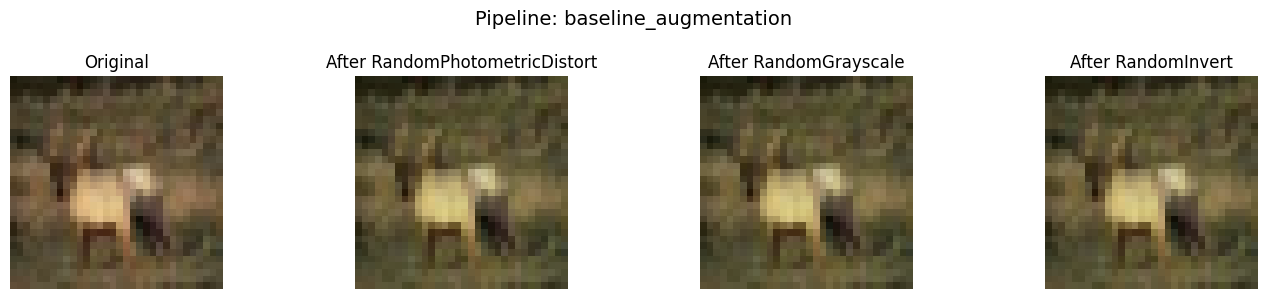

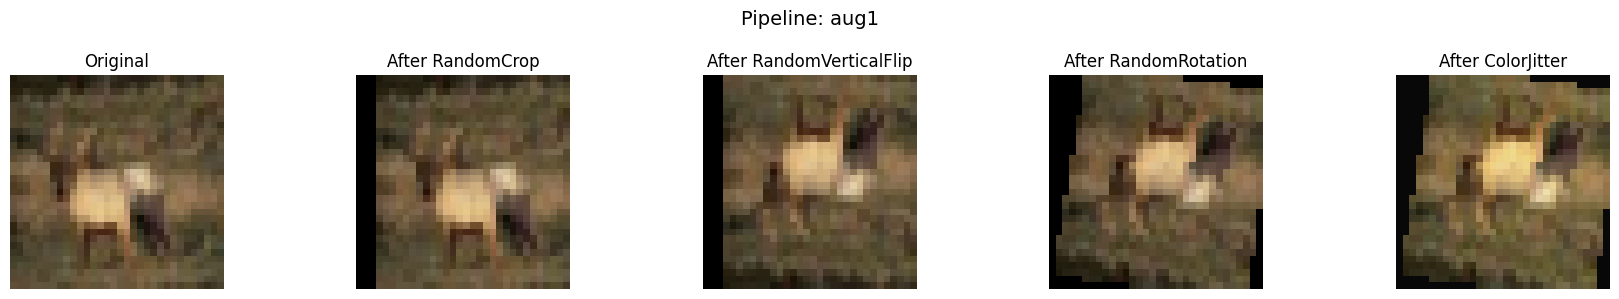

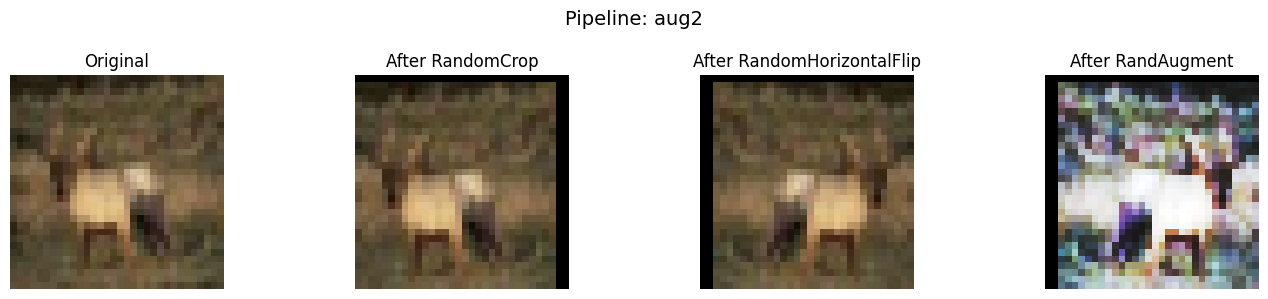

In [7]:
base_ops = [
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
]

augmentation_strategies = {
    "baseline_augmentation": v2.Compose([
        v2.ToImage(),
        v2.RandomPhotometricDistort(),
        v2.RandomGrayscale(p=0.2),
        v2.RandomInvert(p=0.2),
        *base_ops]),

    "aug1": v2.Compose([
        v2.ToImage(),
        v2.RandomCrop(32, padding=4),
        v2.RandomVerticalFlip(),
        v2.RandomRotation(degrees=20),
        v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        *base_ops
    ]),

    "aug2": v2.Compose([
        v2.ToImage(),
        v2.RandomCrop(32, padding=6),
        v2.RandomHorizontalFlip(),
        v2.RandAugment(num_ops=1, magnitude=18),
        *base_ops
    ])
}

# Safely load a single sample image from CIFAR-10 for visualization without relying on downstream cells
temp_dataset = torchvision.datasets.CIFAR10(root=cifar10data, train=True, download=True)
sample_img = Image.fromarray(temp_dataset.data[3])

def visualize_pipeline(name, pipeline, img):
    # We collect images at each step.
    # We skip ToDtype and Normalize to keep colors in uint8 range for matplotlib.
    images = [img]
    titles = ["Original"]

    current = img
    for op in pipeline.transforms:
        # Skip operations that ruin visualization
        if isinstance(op, (v2.ToDtype, v2.Normalize)):
            continue

        current = op(current)

        # We apply ToImage so the tensor conversions work, but we don't need a separate plot for it
        if not isinstance(op, v2.ToImage):
            images.append(current)
            titles.append(f"After {op.__class__.__name__}")

    fig, axes = plt.subplots(1, len(images), figsize=(3.5 * len(images), 3))
    # Ensure axes is iterable even if there's only 1 image (e.g., baseline)
    if len(images) == 1:
        axes = [axes]

    for ax, im, title in zip(axes, images, titles):
        if isinstance(im, torch.Tensor):
            im = im.permute(1, 2, 0).numpy()
        ax.imshow(im)
        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(f"Pipeline: {name}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize all three configurations
for name, strategy in augmentation_strategies.items():
    visualize_pipeline(name, strategy, sample_img)

# Defining Three Optimizers

In [8]:
optimizers = {
    # Baseline, no change needed
    "baseline_sgd_momentum": lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    # Set the initial learning rate to 0.001.
    "adam": lambda params: optim.Adam(params, lr=0.001),
    # Set the initial learning rate to 0.001.
    "adamw": lambda params: optim.AdamW(params, lr=0.001, weight_decay=0.01)
}

# Selecting Configuration

In [9]:
# All seven configurations are enabled; edit this dictionary to run a subset.
configurations = {
    "Baseline": {"arch": "baseline_simple_cnn", "aug": "baseline_augmentation", "opt": "baseline_sgd_momentum"},
    "MobileNetV3": {"arch": "mobilenet_v3", "aug": "baseline_augmentation", "opt": "baseline_sgd_momentum"},
    "DenseNet121": {"arch": "densenet121", "aug": "baseline_augmentation", "opt": "baseline_sgd_momentum"},
    "Aug1": {"arch": "baseline_simple_cnn", "aug": "aug1", "opt": "baseline_sgd_momentum"},
    "Aug2": {"arch": "baseline_simple_cnn", "aug": "aug2", "opt": "baseline_sgd_momentum"},
    "Adam": {"arch": "baseline_simple_cnn", "aug": "baseline_augmentation", "opt": "adam"},
    "AdamW": {"arch": "baseline_simple_cnn", "aug": "baseline_augmentation", "opt": "adamw"}
}

# Reference baseline transform; run_experiment chooses the transform for each run.
train_transform = augmentation_strategies["baseline_augmentation"]

# 1 Pre Processing

## 1.2 Seeding

In [10]:
experiment_seeds = [0, 1, 2]
small_experiment_seeds = [1]

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

current_seed = experiment_seeds[0]
set_seed(current_seed)

## 1.3 CIFAR-10 Dataset

### 1.3.1 Downloading and Transforming

In [11]:
# Transform for validation and test data (NO augmentations)
eval_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Leave the training transform unset; run_experiment assigns it for each configuration.
full_trainset_aug = torchvision.datasets.CIFAR10(root=cifar10data, train=True, download=False, transform=None)
full_trainset_eval = torchvision.datasets.CIFAR10(root=cifar10data, train=True, download=False, transform=eval_transform)

from sklearn.model_selection import train_test_split

# One fixed class-stratified split, shared by all configurations and seeds.
train_idx, val_idx = train_test_split(
    np.arange(len(full_trainset_aug)), test_size=0.1, random_state=42,
    stratify=full_trainset_aug.targets
)

trainset = torch.utils.data.Subset(full_trainset_aug, train_idx)    # map the training indices to the augmented data
valset = torch.utils.data.Subset(full_trainset_eval, val_idx)       # map the valuation indices to the normalized data

# The test set only uses the evaluation transform
testset = torchvision.datasets.CIFAR10(root=cifar10data, train=False, download=False, transform=eval_transform)

In [12]:
batch_size = 128

### 1.3.2 Step by Step Inspection for understanding underlying data

In [13]:
print("--Before Transformation Shape and Dtype--\n ---------------------------------------")
from PIL import Image
pimg = Image.fromarray(full_trainset_aug.data[0])
plabel = full_trainset_aug.targets[0]
print(type(pimg))
print(f"Size (W, H): {pimg.size}")
print(f"Mode: {pimg.mode}")

print("\n--After Transformation Shape and Dtype (Applying Baseline)--\n ---------------------------------------")
# The training dataset has no default transform, so apply the baseline augmentation
# explicitly here to inspect its output.
temp_transform = augmentation_strategies["baseline_augmentation"]
img_pil, label = trainset[0]
img = temp_transform(img_pil)

print(type(img))
print(f"Shape: {img.shape}")
print(f"Dtype: {img.dtype}")

step1_to_image = v2.ToImage()
step2_to_dtype = v2.ToDtype(torch.float32, scale=True)
step3_normalize = v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

img_t1 = step1_to_image(pimg)
img_t2 = step2_to_dtype(img_t1)
img_t3 = step3_normalize(img_t2)

print("\n-- Step-by-Step --")
print(f"After ToImage:   type={type(img_t1)}, shape={img_t1.shape}, dtype={img_t1.dtype}, min={img_t1.min()}, max={img_t1.max()}")
print(f"After ToDtype:   type={type(img_t2)}, shape={img_t2.shape}, dtype={img_t2.dtype}, min={img_t2.min():.2f}, max={img_t2.max():.2f}")
print(f"After Normalize: type={type(img_t3)}, shape={img_t3.shape}, dtype={img_t3.dtype}, min={img_t3.min():.2f}, max={img_t3.max():.2f}")

--Before Transformation Shape and Dtype--
 ---------------------------------------
<class 'PIL.Image.Image'>
Size (W, H): (32, 32)
Mode: RGB

--After Transformation Shape and Dtype (Applying Baseline)--
 ---------------------------------------
<class 'torchvision.tv_tensors._image.Image'>
Shape: torch.Size([3, 32, 32])
Dtype: torch.float32

-- Step-by-Step --
After ToImage:   type=<class 'torchvision.tv_tensors._image.Image'>, shape=torch.Size([3, 32, 32]), dtype=torch.uint8, min=0, max=255
After ToDtype:   type=<class 'torchvision.tv_tensors._image.Image'>, shape=torch.Size([3, 32, 32]), dtype=torch.float32, min=0.00, max=1.00
After Normalize: type=<class 'torchvision.tv_tensors._image.Image'>, shape=torch.Size([3, 32, 32]), dtype=torch.float32, min=-1.00, max=1.00


## 1.4 Training and evaluation setup

In [14]:
import csv
import json
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

device = DEVICE
epochs = 25
patience = 6
scheduler_patience = 3
lr_factor = 0.1

def run_experiment(config_name, config, seed):
    set_seed(seed)
    full_trainset_aug.transform = augmentation_strategies[config["aug"]]

    num_workers_detected = os.cpu_count() if os.cpu_count() is not None else 2

    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers= num_workers_detected, pin_memory=True) #num_workers_detected)
    valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers= num_workers_detected, pin_memory=True) #num_workers_detected)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers= num_workers_detected, pin_memory=True) #num_workers_detected)

    model = architectures[config["arch"]]().to(device)
    optimiser = optimizers[config["opt"]](model.parameters())
    initial_lr = optimiser.param_groups[0]["lr"]
    weight_decay = optimiser.param_groups[0]["weight_decay"]
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode="min", factor=lr_factor, patience=scheduler_patience
    )
    params = sum(param.numel() for param in model.parameters())
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    epoch_durations = []
    start = time.perf_counter()

    for epoch in range(epochs):
        epoch_start = time.perf_counter()
        model.train()
        train_loss = torch.zeros((), device=device)
        correct_train = torch.zeros((), device=device, dtype=torch.long)
        total_train = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimiser.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimiser.step()
            train_loss += loss.detach() * labels.size(0)
            total_train += labels.size(0)
            correct_train += outputs.argmax(1).eq(labels).sum()

        model.eval()
        val_loss = torch.zeros((), device=device)
        correct_val = torch.zeros((), device=device, dtype=torch.long)
        total_val = 0
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels) * labels.size(0)
                total_val += labels.size(0)
                correct_val += outputs.argmax(1).eq(labels).sum()

        average_train_loss = (train_loss / total_train).item()
        average_val_loss = (val_loss / total_val).item()
        history["train_loss"].append(average_train_loss)
        history["val_loss"].append(average_val_loss)
        history["train_acc"].append(100 * correct_train.item() / total_train)
        history["val_acc"].append(100 * correct_val.item() / total_val)
        scheduler.step(average_val_loss)

        epoch_end = time.perf_counter()
        epoch_duration = epoch_end - epoch_start
        epoch_durations.append(epoch_duration)

        print(f"{config_name} seed {seed} epoch {epoch + 1}/{epochs}: "
              f"train loss {average_train_loss:.4f}, val loss {average_val_loss:.4f}, "
              f"val acc {history['val_acc'][-1]:.2f}% ({epoch_duration:.1f}s)")

        if average_val_loss < best_val_loss:
            best_val_loss = average_val_loss
            patience_counter = 0
            best_model_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    train_seconds = time.perf_counter() - start
    model.load_state_dict(best_model_state)
    model.eval()
    test_labels, test_predictions = [], []
    with torch.no_grad():
        for inputs, labels in testloader:
            outputs = model(inputs.to(device))
            test_labels.extend(labels.tolist())
            test_predictions.extend(outputs.argmax(1).cpu().tolist())

    avg_epoch_time = sum(epoch_durations) / len(epoch_durations) if epoch_durations else 0

    result = {
        "configuration": config_name, "seed": seed, **config, "params": params,
        "learning_rate": initial_lr, "weight_decay": weight_decay,
        "epochs_trained": len(history["val_loss"]), "train_seconds": round(train_seconds, 1),
        "avg_epoch_seconds": round(avg_epoch_time, 1),
        "best_val_loss": best_val_loss,
        "accuracy": 100 * accuracy_score(test_labels, test_predictions),
        "macro_f1": f1_score(test_labels, test_predictions, average="macro"),
    }
    return result, history, test_predictions

# 2. Run the experiments
Each configuration is trained with three seeds. The training cell saves one row per run to `results.csv` and keeps the histories and test predictions in memory for the results below. Running it again replaces that CSV.

In [15]:
# Run seven configurations x three seeds; one CSV row per completed run.
results, histories, predictions = [], {}, {}
with open("results.csv", "w", newline="") as file:
    writer = None
    for config_name, config in configurations.items():
        for seed in experiment_seeds:
            result, history, test_predictions = run_experiment(config_name, config, seed)
            histories[(config_name, seed)] = history
            predictions[(config_name, seed)] = test_predictions
            results.append(result)
            if writer is None:
                writer = csv.DictWriter(file, fieldnames=[*result, "history"])
                writer.writeheader()
            writer.writerow({**result, "history": json.dumps(history)})
            file.flush()
            print(f"{config_name} seed {seed}: test acc {result['accuracy']:.2f}%, "
                  f"macro-F1 {result['macro_f1']:.3f}")

studies = {
    "Architecture": ["Baseline", "MobileNetV3", "DenseNet121"],
    "Augmentation": ["Baseline", "Aug1", "Aug2"],
    "Optimiser": ["Baseline", "Adam", "AdamW"],
}

Baseline seed 0 epoch 1/25: train loss 2.2393, val loss 1.9474, val acc 33.26% (10.2s)
Baseline seed 0 epoch 2/25: train loss 1.9143, val loss 1.5564, val acc 45.00% (9.7s)
Baseline seed 0 epoch 3/25: train loss 1.6588, val loss 1.3444, val acc 53.48% (9.2s)
Baseline seed 0 epoch 4/25: train loss 1.4485, val loss 1.1693, val acc 59.98% (9.5s)
Baseline seed 0 epoch 5/25: train loss 1.2980, val loss 1.0788, val acc 63.24% (9.5s)
Baseline seed 0 epoch 6/25: train loss 1.1807, val loss 0.9757, val acc 66.86% (9.2s)
Baseline seed 0 epoch 7/25: train loss 1.0815, val loss 0.9075, val acc 69.36% (9.5s)
Baseline seed 0 epoch 8/25: train loss 1.0072, val loss 0.8573, val acc 70.50% (9.3s)
Baseline seed 0 epoch 9/25: train loss 0.9422, val loss 0.8086, val acc 71.30% (9.1s)
Baseline seed 0 epoch 10/25: train loss 0.8718, val loss 0.7810, val acc 72.78% (9.4s)
Baseline seed 0 epoch 11/25: train loss 0.8202, val loss 0.7684, val acc 73.16% (9.4s)
Baseline seed 0 epoch 12/25: train loss 0.7762, val

# 3. Results
Comparison tables report test accuracy and macro-F1 as mean ± sample standard deviation over all three seeds. The plots and confusion matrices below all use **one shared seed** (`plot_seed`, set in the next cell). The best and worst configurations for per-class metrics are selected by mean validation loss, not test performance. Results cells use the histories and predictions kept in memory by the training cell; rerun them after training to replace older saved outputs.

## 3.1 Three-seed comparisons

In [16]:
from IPython.display import Markdown, display

# Use the same seed for every curve, confusion matrix, and per-class report.
plot_seed = experiment_seeds[0]

# Compare the three one-factor-at-a-time studies across all seeds (ddof=1).
for study, names in studies.items():
    rows = [
        "| Configuration | Parameters | Accuracy (%) | Macro-F1 | Training (s) | Seconds/epoch |",
        "|:--|--:|--:|--:|--:|--:|",
    ]
    for name in names:
        runs = [row for row in results if row["configuration"] == name]
        accs = [row["accuracy"] for row in runs]
        f1s = [row["macro_f1"] for row in runs]
        rows.append(
            f"| {name} | {runs[0]['params']:,} | "
            f"{np.mean(accs):.2f} ± {np.std(accs, ddof=1):.2f} | "
            f"{np.mean(f1s):.3f} ± {np.std(f1s, ddof=1):.3f} | "
            f"{np.mean([row['train_seconds'] for row in runs]):.1f} | "
            f"{np.mean([row['avg_epoch_seconds'] for row in runs]):.1f} |"
        )
    display(Markdown(f"### {study}\n\n" + "\n".join(rows)))

### Architecture

| Configuration | Parameters | Accuracy (%) | Macro-F1 | Training (s) | Seconds/epoch |
|:--|--:|--:|--:|--:|--:|
| Baseline | 4,702,582 | 75.40 ± 0.45 | 0.752 ± 0.005 | 214.8 | 9.3 |
| MobileNetV3 | 4,214,842 | 75.83 ± 1.56 | 0.757 ± 0.019 | 283.8 | 15.5 |
| DenseNet121 | 6,956,426 | 84.58 ± 0.06 | 0.846 ± 0.000 | 672.9 | 34.2 |

### Augmentation

| Configuration | Parameters | Accuracy (%) | Macro-F1 | Training (s) | Seconds/epoch |
|:--|--:|--:|--:|--:|--:|
| Baseline | 4,702,582 | 75.40 ± 0.45 | 0.752 ± 0.005 | 214.8 | 9.3 |
| Aug1 | 4,702,582 | 69.74 ± 0.50 | 0.692 ± 0.008 | 380.3 | 15.2 |
| Aug2 | 4,702,582 | 75.26 ± 0.70 | 0.750 ± 0.006 | 179.4 | 7.2 |

### Optimiser

| Configuration | Parameters | Accuracy (%) | Macro-F1 | Training (s) | Seconds/epoch |
|:--|--:|--:|--:|--:|--:|
| Baseline | 4,702,582 | 75.40 ± 0.45 | 0.752 ± 0.005 | 214.8 | 9.3 |
| Adam | 4,702,582 | 77.71 ± 0.34 | 0.776 ± 0.003 | 203.3 | 9.0 |
| AdamW | 4,702,582 | 77.33 ± 0.65 | 0.772 ± 0.007 | 200.4 | 9.0 |

## 3.2 Training versus validation loss
One panel per configuration (seven total). Both curves in every panel come from the same `plot_seed` chosen above; early stopping can give different numbers of epochs.

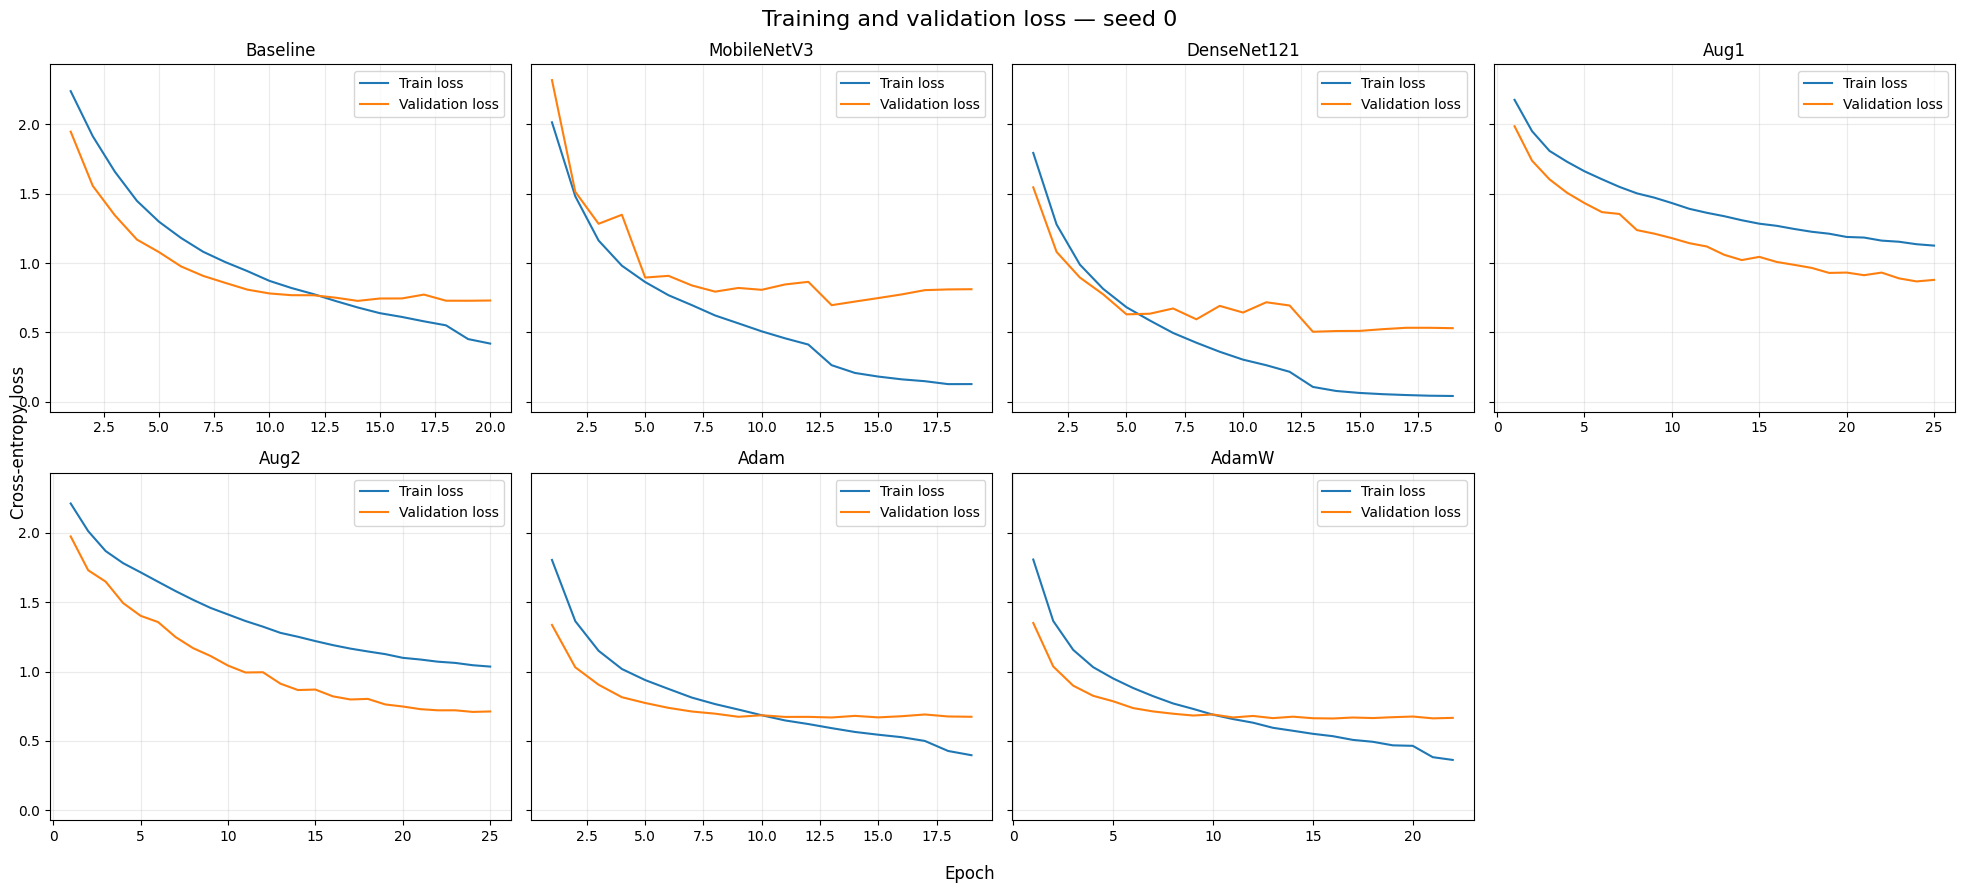

In [17]:
config_names = list(configurations)
fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharey=True)
for name, ax in zip(config_names, axes.flat):
    history = histories[(name, plot_seed)]
    epoch_numbers = range(1, len(history["train_loss"]) + 1)
    ax.plot(epoch_numbers, history["train_loss"], label="Train loss")
    ax.plot(epoch_numbers, history["val_loss"], label="Validation loss")
    ax.set_title(name)
    ax.grid(alpha=0.25)
    ax.legend()
for ax in axes.flat[len(config_names):]:
    ax.axis("off")
fig.suptitle(f"Training and validation loss — seed {plot_seed}", fontsize=16)
fig.supxlabel("Epoch")
fig.supylabel("Cross-entropy loss")
fig.tight_layout()
plt.show()

## 3.3 Test-set confusion matrices
One matrix per configuration, using the **same seed** as the loss curves. Rows are true CIFAR-10 classes and columns are predicted classes. Each row is normalised to 100%, so its diagonal is the recall for that class. All seven matrices use the same colour scale.

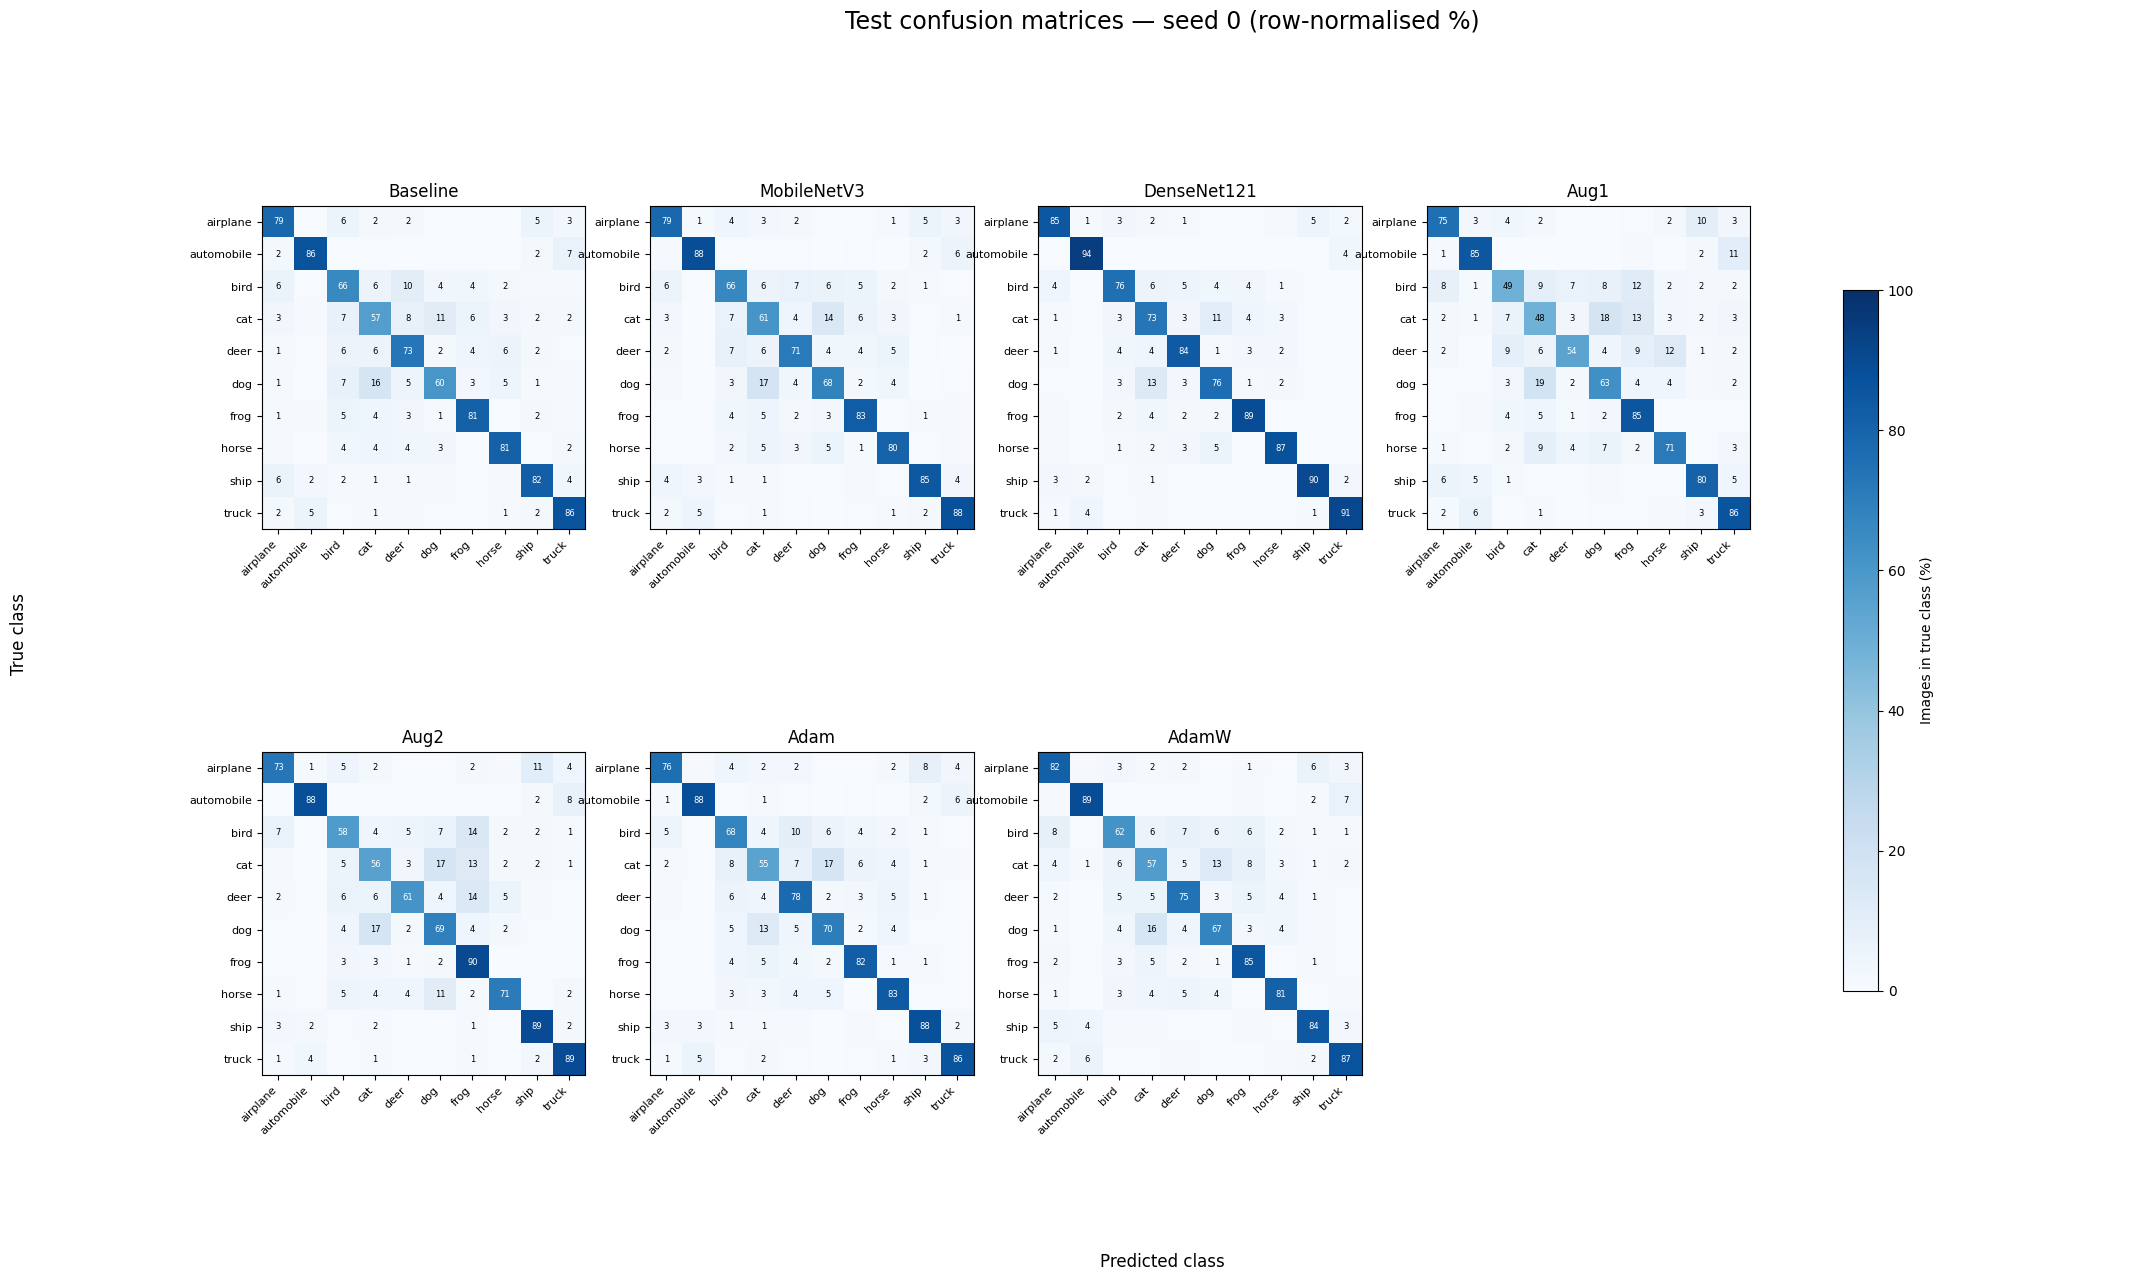

In [18]:
from sklearn.metrics import confusion_matrix

class_names = testset.classes
fig, axes = plt.subplots(2, 4, figsize=(24, 13))
flat_axes = axes.ravel()
for name, ax in zip(config_names, flat_axes):
    matrix = confusion_matrix(
        testset.targets, predictions[(name, plot_seed)],
        labels=range(len(class_names)), normalize="true"
    ) * 100
    image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=100)
    ax.set_title(name)
    ax.set_xticks(range(len(class_names)), class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(class_names)), class_names, fontsize=8)
    for (true_idx, pred_idx), value in np.ndenumerate(matrix):
        if value >= 1:
            ax.text(pred_idx, true_idx, f"{value:.0f}", ha="center", va="center",
                    fontsize=6, color="white" if value > 50 else "black")
for ax in flat_axes[len(config_names):]:
    ax.axis("off")
fig.suptitle(f"Test confusion matrices — seed {plot_seed} (row-normalised %)", fontsize=17)
fig.supxlabel("Predicted class")
fig.supylabel("True class")
fig.colorbar(image, ax=flat_axes[:len(config_names)].tolist(), shrink=0.7,
             label="Images in true class (%)")
plt.show()

## 3.4 Per-class precision and recall
The assignment requires per-class precision and recall for at least the best and worst configurations. These are selected using **mean validation loss over the three seeds**, then evaluated using the same representative seed as the plots.

In [19]:
mean_val_loss = {name: np.mean([row["best_val_loss"] for row in results
                                if row["configuration"] == name]) for name in config_names}
best_name = min(mean_val_loss, key=mean_val_loss.get)
worst_name = max(mean_val_loss, key=mean_val_loss.get)
for label, name in [("Lowest mean validation loss", best_name),
                    ("Highest mean validation loss", worst_name)]:
    precision, recall, _, _ = precision_recall_fscore_support(
        testset.targets, predictions[(name, plot_seed)],
        labels=range(len(class_names)), zero_division=0
    )
    rows = ["| Class | Precision | Recall |", "|:--|--:|--:|"]
    rows += [f"| {class_name} | {p:.3f} | {r:.3f} |"
             for class_name, p, r in zip(class_names, precision, recall)]
    display(Markdown(f"### {label}: {name} (seed {plot_seed})\n\n" + "\n".join(rows)))

### Lowest mean validation loss: DenseNet121 (seed 0)

| Class | Precision | Recall |
|:--|--:|--:|
| airplane | 0.867 | 0.848 |
| automobile | 0.920 | 0.944 |
| bird | 0.817 | 0.756 |
| cat | 0.693 | 0.732 |
| deer | 0.826 | 0.839 |
| dog | 0.761 | 0.765 |
| frog | 0.871 | 0.889 |
| horse | 0.894 | 0.868 |
| ship | 0.905 | 0.902 |
| truck | 0.905 | 0.909 |

### Highest mean validation loss: Aug1 (seed 0)

| Class | Precision | Recall |
|:--|--:|--:|
| airplane | 0.769 | 0.754 |
| automobile | 0.823 | 0.850 |
| bird | 0.621 | 0.491 |
| cat | 0.491 | 0.485 |
| deer | 0.744 | 0.544 |
| dog | 0.608 | 0.631 |
| frog | 0.668 | 0.852 |
| horse | 0.736 | 0.711 |
| ship | 0.788 | 0.805 |
| truck | 0.733 | 0.861 |